In [1]:
# ── Notebook 6: Mechanistic Analysis ──────────────────────────────────────
# Three original analyses that go beyond the paper's scope:
#
# 6a — Vowel Harmony Ablation (Telugu)
#      How many bits does vowel harmony contribute to Telugu's complexity?
#      Replicates + extends Paper Study 3 (Turkish ablation) to Dravidian.
#
# 6b — Syllable Boundary Entropy
#      Does Indic complexity come from consonant positions or vowel positions?
#      Tests whether syllabification matters for Indic (unlike Dutch/Min).
#
# 6c — Retroflex Positional Entropy
#      What % of Hindi/Telugu complexity is driven by the retroflex series?
#      First mechanistic decomposition of this kind in the literature.
# ───────────────────────────────────────────────────────────────────────────

import json, math, random
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import torch
import torch.nn as nn
import torch.optim as optim

# ── Constants ──────────────────────────────────────────────────────────────
LANGUAGES   = ["hin", "tam", "tel", "eng"]
LANG_NAMES  = {"hin": "Hindi", "tam": "Tamil", "tel": "Telugu", "eng": "English"}
LANG_COLORS = {"hin": "#E63946", "tam": "#2A9D8F", "tel": "#F4A261", "eng": "#457B9D"}
BOS, EOS    = "<s>", "</s>"
N_FOLDS     = 10
RANDOM_SEED = 42
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── Paths — adjust to match your /kaggle/input/ sidebar ───────────────────
NB1 = "/kaggle/input/notebooks/tanveerheir/data-pipeline"
NB2 = "/kaggle/input/notebooks/tanveerheir/trigramlm"
NB3 = "/kaggle/input/notebooks/tanveerheir/lstm-model"

# ── Load all previous outputs ──────────────────────────────────────────────
with open(f"{NB1}/forms.json", encoding="utf-8") as f:
    forms = json.load(f)
with open(f"{NB1}/vocab.json", encoding="utf-8") as f:
    vocab = json.load(f)
with open(f"{NB1}/folds.json") as f:
    folds_raw = json.load(f)
with open(f"{NB2}/ngram_results.json") as f:
    ngram_results = json.load(f)
with open(f"{NB3}/lstm_results.json") as f:
    lstm_results = json.load(f)

# ── Rebuild splits ─────────────────────────────────────────────────────────
def get_split_words(lang_entries, concept_set):
    return [e["phonemes"] for e in lang_entries if e["concept"] in concept_set]

splits = {}
for lid in LANGUAGES:
    splits[lid] = []
    for fold in folds_raw:
        splits[lid].append({
            "train": get_split_words(forms[lid], set(fold["train"])),
            "test" : get_split_words(forms[lid], set(fold["test"])),
        })

print(f"Device: {DEVICE}")
print("All previous outputs loaded.")
print()
print("This notebook contains 3 analyses:")
print("  6a — Vowel Harmony Ablation (Telugu)")
print("  6b — Syllable Boundary Entropy")
print("  6c — Retroflex Positional Entropy")

Device: cuda
All previous outputs loaded.

This notebook contains 3 analyses:
  6a — Vowel Harmony Ablation (Telugu)
  6b — Syllable Boundary Entropy
  6c — Retroflex Positional Entropy


In [2]:
class PhonemeEncoder:
    def __init__(self, phonemes_list):
        all_phon = set(p for word in phonemes_list for p in word)
        all_phon.update([BOS, EOS])
        self.stoi = {p: i for i, p in enumerate(sorted(all_phon))}
        self.itos = {i: p for p, i in self.stoi.items()}
        self.size = len(self.stoi)

    def encode(self, phonemes):
        ids = ([self.stoi[BOS]] +
               [self.stoi[p] for p in phonemes] +
               [self.stoi[EOS]])
        return torch.tensor(ids, dtype=torch.long, device=DEVICE)

    def __len__(self):
        return self.size


class LSTMPhonemeLM(nn.Module):
    def __init__(self, vocab_size, emb_dim=32, hidden_dim=64, dropout=0.5):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.lstm    = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.out     = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb    = self.dropout(self.embed(x))
        h, _   = self.lstm(emb)
        return self.out(h.squeeze(0))


def train_lstm(train_words, encoder, epochs=15, lr=0.005, patience=3):
    val_split   = max(1, len(train_words) // 10)
    val_words   = train_words[:val_split]
    train_words = train_words[val_split:]

    model     = LSTMPhonemeLM(len(encoder)).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_state    = None
    no_improve    = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for idx in torch.randperm(len(train_words)):
            word   = train_words[idx.item()]
            seq    = encoder.encode(word)
            x, y   = seq[:-1].unsqueeze(0), seq[1:]
            loss   = criterion(model(x), y)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for word in val_words:
                if not all(p in encoder.stoi for p in word):
                    continue
                seq  = encoder.encode(word)
                x, y = seq[:-1].unsqueeze(0), seq[1:]
                val_loss += criterion(model(x), y).item()
        val_loss /= max(len(val_words), 1)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    if best_state:
        model.load_state_dict(best_state)
    return model


@torch.no_grad()
def eval_lstm(model, test_words, encoder):
    model.eval()
    total_bits, total_phonemes = 0.0, 0
    per_word = []
    for word in test_words:
        seq       = encoder.encode(word)
        x, y      = seq[:-1].unsqueeze(0), seq[1:]
        logits    = model(x)
        log_probs = torch.log_softmax(logits, dim=-1)
        token_lp  = log_probs[range(len(y)), y]
        word_bits = (-token_lp / math.log(2)).sum().item()
        per_word.append(word_bits / len(y))
        total_bits     += word_bits
        total_phonemes += len(y)
    return total_bits / total_phonemes, per_word


print("LSTM classes ready.")

LSTM classes ready.


In [3]:
# ── IPA vowel set — covers all vowels appearing in our 4 languages ─────────
# These are the IPA symbols that represent vowel sounds
IPA_VOWELS = {
    "a", "aː", "ã", "ãː", "æ", "e", "eː", "ẽ", "ẽː", "ɛ", "ɛː", "ɛ̃ː",
    "i", "iː", "ĩ", "ĩː", "ɪ", "ɪ̃", "o", "oː", "õ", "õː", "ɔ", "ɔː",
    "u", "uː", "ũ", "ũː", "ʊ", "ʊ̃", "ə", "əũ", "ə̃", "ɑ", "ɑː",
    "ʌ", "ʌ̃", "ɐ", "ai", "au",
    # Telugu-specific
    "ĩ", "ũ", "õ",
}

def scramble_vowels(phonemes, vowel_set, rng):
    """
    Break vowel harmony by randomly shuffling all vowels within a word.
    Consonants stay in place. Only vowel positions are shuffled.
    
    Example:
      Original:  k a l a m a  (vowels: a a a — all same, harmony intact)
      Scrambled: k i l a m u  (vowels: i a u — random, harmony broken)
    """
    vowel_positions = [i for i, p in enumerate(phonemes) if p in vowel_set]
    if len(vowel_positions) < 2:
        return phonemes   # nothing to scramble with 0 or 1 vowels

    vowels = [phonemes[i] for i in vowel_positions]
    rng.shuffle(vowels)

    result = list(phonemes)
    for pos, new_vowel in zip(vowel_positions, vowels):
        result[pos] = new_vowel
    return result


# Demo on a real Telugu word
tel_example = forms["tel"][0]["phonemes"]
rng = random.Random(42)
scrambled = scramble_vowels(tel_example, IPA_VOWELS, rng)

print("Vowel harmony ablation demo (Telugu):")
print(f"  Original:  {' '.join(tel_example)}")
print(f"  Scrambled: {' '.join(scrambled)}")
print()
print(f"Vowels in original:  "
      f"{[p for p in tel_example if p in IPA_VOWELS]}")
print(f"Vowels in scrambled: "
      f"{[p for p in scrambled if p in IPA_VOWELS]}")

Vowel harmony ablation demo (Telugu):
  Original:  k ʌ n̪ː u
  Scrambled: k u n̪ː ʌ

Vowels in original:  ['ʌ', 'u']
Vowels in scrambled: ['u', 'ʌ']


In [4]:
print("Running vowel harmony ablation...")
print("Languages: Telugu (has harmony), Hindi (partial), English (none)")
print("This takes ~3 minutes on GPU\n")

ablation_results = {}   # lang -> list of (normal_bpp, scrambled_bpp) per fold
rng = random.Random(RANDOM_SEED)

for lid in ["tel", "hin", "eng"]:
    print(f"\n── {LANG_NAMES[lid]} ──────────────────────────")
    fold_normal    = []
    fold_scrambled = []

    for fold_i, fold_data in enumerate(splits[lid]):
        train_words = fold_data["train"]
        test_words  = fold_data["test"]

        encoder = PhonemeEncoder(train_words)

        # Filter OOV
        test_filtered = [w for w in test_words
                         if all(p in encoder.stoi for p in w)]

        # Scramble test words — consonants stay, vowels shuffled
        test_scrambled = [
            scramble_vowels(w, IPA_VOWELS, rng)
            for w in test_filtered
        ]

        # Filter scrambled words for OOV
        # (scrambling can introduce vowels not in training vocab)
        test_scrambled_filtered = [
            w for w in test_scrambled
            if all(p in encoder.stoi for p in w)
        ]

        # Train on normal words
        model = train_lstm(train_words, encoder, epochs=15, patience=3)

        # Evaluate on normal and scrambled
        bpp_normal,    _ = eval_lstm(model, test_filtered,           encoder)
        bpp_scrambled, _ = eval_lstm(model, test_scrambled_filtered, encoder)

        fold_normal.append(bpp_normal)
        fold_scrambled.append(bpp_scrambled)
        print(f"  Fold {fold_i+1:>2}: normal={bpp_normal:.3f}  "
              f"scrambled={bpp_scrambled:.3f}  "
              f"diff={bpp_scrambled-bpp_normal:+.3f}")

    ablation_results[lid] = {
        "normal"   : fold_normal,
        "scrambled": fold_scrambled,
    }

    mean_n = np.mean(fold_normal)
    mean_s = np.mean(fold_scrambled)
    print(f"\n  {LANG_NAMES[lid]} SUMMARY:")
    print(f"    Normal:    {mean_n:.3f} ± {np.std(fold_normal):.3f}")
    print(f"    Scrambled: {mean_s:.3f} ± {np.std(fold_scrambled):.3f}")
    print(f"    Harmony contribution: {mean_s - mean_n:+.3f} bits/phoneme")

Running vowel harmony ablation...
Languages: Telugu (has harmony), Hindi (partial), English (none)
This takes ~3 minutes on GPU


── Telugu ──────────────────────────
  Fold  1: normal=3.313  scrambled=4.146  diff=+0.833
  Fold  2: normal=3.398  scrambled=3.978  diff=+0.579
  Fold  3: normal=3.182  scrambled=3.927  diff=+0.745
  Fold  4: normal=3.485  scrambled=4.046  diff=+0.561
  Fold  5: normal=3.295  scrambled=3.826  diff=+0.532
  Fold  6: normal=3.262  scrambled=3.827  diff=+0.565
  Fold  7: normal=3.427  scrambled=4.129  diff=+0.703
  Fold  8: normal=3.348  scrambled=3.897  diff=+0.548
  Fold  9: normal=3.228  scrambled=3.928  diff=+0.700
  Fold 10: normal=3.181  scrambled=3.911  diff=+0.730

  Telugu SUMMARY:
    Normal:    3.312 ± 0.098
    Scrambled: 3.961 ± 0.107
    Harmony contribution: +0.649 bits/phoneme

── Hindi ──────────────────────────
  Fold  1: normal=3.825  scrambled=4.266  diff=+0.441
  Fold  2: normal=3.621  scrambled=3.997  diff=+0.376
  Fold  3: normal=3.812  

── Vowel Harmony Ablation Results ─────────────────────────────

Language     Normal  Scrambled   Harmony contrib   vs Turkish (+0.62)
----------------------------------------------------------------------
Telugu        3.312      3.961            +0.649               +0.029
Hindi         3.708      4.036            +0.328               -0.292
English       3.460      3.894            +0.434               -0.186

Turkish (paper Study 3): +0.620 bits/phoneme

Interpretation:
  Positive contribution = vowel harmony was reducing entropy
  Larger value = harmony plays bigger role in that language


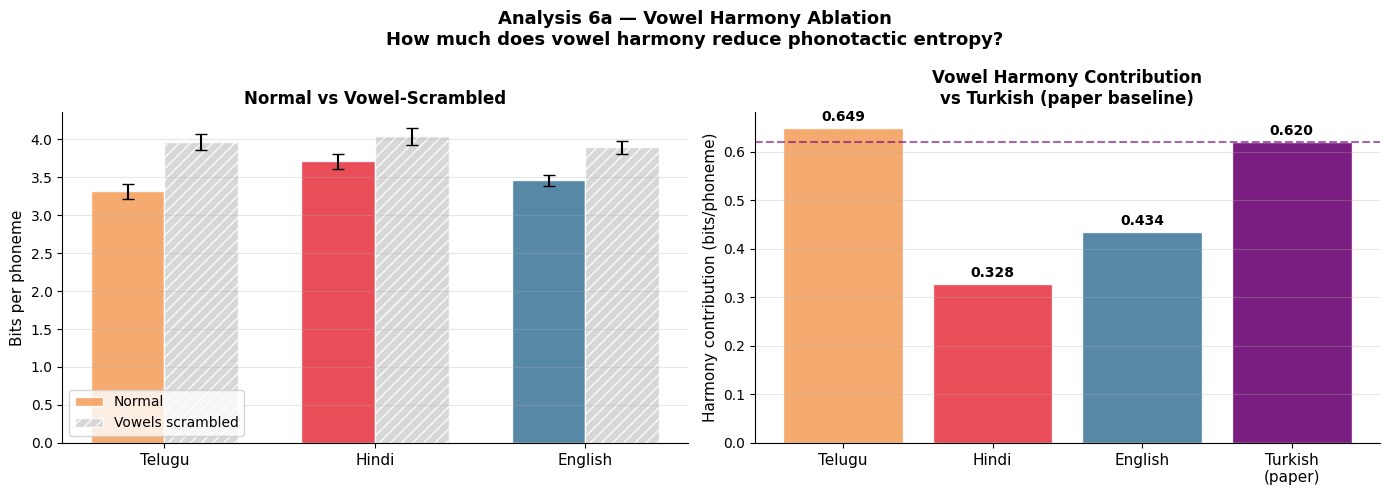

Saved: fig9_vowel_harmony_ablation.png


In [15]:
print("── Vowel Harmony Ablation Results ─────────────────────────────")
print()
print(f"{'Language':<10} {'Normal':>8} {'Scrambled':>10} "
      f"{'Harmony contrib':>17} {'vs Turkish (+0.62)':>20}")
print("-" * 70)

harmony_contributions = {}
for lid in ["tel", "hin", "eng"]:
    n = np.mean(ablation_results[lid]["normal"])
    s = np.mean(ablation_results[lid]["scrambled"])
    contrib = s - n
    harmony_contributions[lid] = contrib
    vs_turkish = contrib - 0.62
    print(f"{LANG_NAMES[lid]:<10} {n:>8.3f} {s:>10.3f} "
          f"{contrib:>+17.3f} {vs_turkish:>+20.3f}")

print()
print("Turkish (paper Study 3): +0.620 bits/phoneme")
print()
print("Interpretation:")
print("  Positive contribution = vowel harmony was reducing entropy")
print("  Larger value = harmony plays bigger role in that language")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Analysis 6a — Vowel Harmony Ablation\n"
             "How much does vowel harmony reduce phonotactic entropy?",
             fontsize=13, fontweight="bold")

# Left: before/after bars
ax = axes[0]
langs_plot = ["tel", "hin", "eng"]
x = np.arange(len(langs_plot))
width = 0.35

normal_means    = [np.mean(ablation_results[l]["normal"])    for l in langs_plot]
scrambled_means = [np.mean(ablation_results[l]["scrambled"]) for l in langs_plot]
normal_stds     = [np.std(ablation_results[l]["normal"])     for l in langs_plot]
scrambled_stds  = [np.std(ablation_results[l]["scrambled"])  for l in langs_plot]

b1 = ax.bar(x - width/2, normal_means, width, yerr=normal_stds,
            label="Normal", color=[LANG_COLORS[l] for l in langs_plot],
            alpha=0.9, edgecolor="white", capsize=4)
b2 = ax.bar(x + width/2, scrambled_means, width, yerr=scrambled_stds,
            label="Vowels scrambled", color="lightgray",
            alpha=0.9, edgecolor="white", capsize=4,
            hatch="///")

ax.set_xticks(x)
ax.set_xticklabels([LANG_NAMES[l] for l in langs_plot], fontsize=11)
ax.set_ylabel("Bits per phoneme", fontsize=11)
ax.set_title("Normal vs Vowel-Scrambled", fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

# Right: harmony contribution bar vs Turkish
ax2 = axes[1]
langs_with_turkish = langs_plot + ["turkish_paper"]
contribs = [harmony_contributions.get(l, None) for l in langs_plot] + [0.62]
colors2  = [LANG_COLORS.get(l, "#888") for l in langs_plot] + ["#6A0572"]
labels2  = [LANG_NAMES.get(l, "Turkish\n(paper)") for l in langs_plot] + ["Turkish\n(paper)"]

bars = ax2.bar(range(len(langs_with_turkish)), contribs,
               color=colors2, edgecolor="white", alpha=0.9)
ax2.bar_label(bars, fmt="{:.3f}", padding=3, fontweight="bold")
ax2.set_xticks(range(len(langs_with_turkish)))
ax2.set_xticklabels(labels2, fontsize=11)
ax2.set_ylabel("Harmony contribution (bits/phoneme)", fontsize=11)
ax2.set_title("Vowel Harmony Contribution\nvs Turkish (paper baseline)",
              fontweight="bold")
ax2.axhline(0.62, color="#6A0572", linestyle="--",
            linewidth=1.5, alpha=0.6, label="Turkish baseline")
ax2.spines[["top","right"]].set_visible(False)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/fig9_vowel_harmony_ablation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig9_vowel_harmony_ablation.png")

In [6]:
def syllabify(phonemes, vowel_set):
    """
    Simple CV-based syllable segmenter.
    Returns list of syllables, each syllable is a list of phonemes.
    
    Algorithm: 
      - A syllable nucleus is a vowel
      - Consonants before a vowel are the onset
      - Consonants after a vowel (before the next vowel) are the coda
      - Word-final consonants attach to the last syllable as coda
    
    Example: k a l a m  →  [k,a] [l,a] [m]
    """
    syllables  = []
    current    = []

    for i, p in enumerate(phonemes):
        current.append(p)
        if p in vowel_set:
            # Close this syllable after the vowel
            # Check if next phoneme is consonant followed by vowel
            # (onset of next syllable) — if so, close here
            syllables.append(current)
            current = []

    if current:
        if syllables:
            syllables[-1].extend(current)  # attach trailing consonants
        else:
            syllables.append(current)

    return syllables


def get_position_labels(phonemes, vowel_set):
    """
    Label each phoneme position as 'onset', 'nucleus', or 'coda'.
    Used to separate entropy by syllable position.
    """
    syllables = syllabify(phonemes, vowel_set)
    labels    = []

    for syl in syllables:
        nucleus_found = False
        for p in syl:
            if p in vowel_set:
                labels.append("nucleus")
                nucleus_found = True
            elif not nucleus_found:
                labels.append("onset")
            else:
                labels.append("coda")

    return labels


# Demo
demo = forms["tel"][5]["phonemes"]
labels = get_position_labels(demo, IPA_VOWELS)
print("Syllable position labeling demo (Telugu):")
print(f"  Word: {' '.join(demo)}")
print(f"  Labels: {labels}")
print()

# Count position distribution per language
print("Position distribution per language:")
print(f"{'Language':<10} {'Onset%':>8} {'Nucleus%':>10} {'Coda%':>8}")
print("-" * 38)

for lid in LANGUAGES:
    all_labels = []
    for e in forms[lid]:
        all_labels.extend(get_position_labels(e["phonemes"], IPA_VOWELS))
    total = len(all_labels)
    c = Counter(all_labels)
    print(f"{LANG_NAMES[lid]:<10} "
          f"{100*c['onset']/total:>7.1f}% "
          f"{100*c['nucleus']/total:>9.1f}% "
          f"{100*c['coda']/total:>7.1f}%")

Syllable position labeling demo (Telugu):
  Word: n̪ aː l u k ʌ
  Labels: ['onset', 'nucleus', 'onset', 'nucleus', 'onset', 'nucleus']

Position distribution per language:
Language     Onset%   Nucleus%    Coda%
--------------------------------------
Hindi         46.8%      41.6%    11.7%
Tamil         45.8%      49.4%     4.9%
Telugu        50.7%      49.3%     0.0%
English       42.0%      38.0%    20.1%


In [7]:
# Re-paste InterpolatedNgramLM from Notebook 2
class InterpolatedNgramLM:
    def __init__(self, n=3):
        self.n = n
        self.counts   = [defaultdict(Counter) for _ in range(n)]
        self.unigrams = Counter()
        self.total    = 0
        self.lambdas  = None

    def _make_sequence(self, phonemes):
        return [BOS] * (self.n - 1) + phonemes + [EOS]

    def _count(self, word_list):
        for phonemes in word_list:
            seq = self._make_sequence(phonemes)
            for i in range(self.n - 1, len(seq)):
                sym = seq[i]
                self.unigrams[sym] += 1
                self.total         += 1
                for order in range(1, self.n):
                    context = tuple(seq[i - order : i])
                    self.counts[order][context][sym] += 1

    def _estimate_lambdas(self, held_out):
        L = [0.0] * self.n
        for phonemes in held_out:
            seq = self._make_sequence(phonemes)
            for i in range(self.n - 1, len(seq)):
                sym   = seq[i]
                probs = []
                p1    = (self.unigrams[sym] - 1) / max(self.total - 1, 1)
                probs.append(p1)
                for order in range(1, self.n):
                    context = tuple(seq[i - order : i])
                    ctx_cnt = sum(self.counts[order][context].values())
                    sym_cnt = self.counts[order][context][sym]
                    probs.append((sym_cnt-1)/(ctx_cnt-1) if ctx_cnt>1 else 0.0)
                L[max(range(self.n), key=lambda j: probs[j])] += 1.0
        total_L = sum(L)
        return [l/total_L for l in L] if total_L > 0 else [1/self.n]*self.n

    def fit(self, word_list):
        split    = max(1, len(word_list) // 10)
        self._count(word_list[split:])
        self.lambdas = self._estimate_lambdas(word_list[:split])
        return self

    def _interp_prob(self, context_full, sym):
        p_uni = (self.unigrams[sym]+1) / (self.total+len(self.unigrams))
        p     = self.lambdas[0] * p_uni
        for order in range(1, self.n):
            context = context_full[-order:]
            ctx_cnt = sum(self.counts[order][context].values())
            p      += self.lambdas[order] * (
                self.counts[order][context][sym]/ctx_cnt if ctx_cnt > 0 else 0.0)
        return max(p, 1e-10)

    def bits_per_position(self, word_list, vowel_set):
        """
        Returns dict: position_label -> list of bits values
        Separates entropy by onset / nucleus / coda position.
        """
        position_bits = defaultdict(list)

        for phonemes in word_list:
            seq    = self._make_sequence(phonemes)
            labels = get_position_labels(phonemes, vowel_set)
            # labels covers only the phonemes (not BOS/EOS padding)
            for i in range(self.n - 1, len(seq) - 1):  # exclude EOS
                context  = tuple(seq[i - self.n + 1 : i])
                sym      = seq[i]
                bits     = -math.log2(self._interp_prob(context, sym))
                phon_idx = i - (self.n - 1)
                if phon_idx < len(labels):
                    position_bits[labels[phon_idx]].append(bits)

        return {pos: np.mean(vals) for pos, vals in position_bits.items()
                if vals}


print("Running syllable boundary entropy analysis...")
print()

positional_results = {}   # lang -> {onset, nucleus, coda} mean bits

for lid in LANGUAGES:
    onset_all = []
    nucleus_all = []
    coda_all = []

    for fold_data in splits[lid]:
        lm = InterpolatedNgramLM(n=3)
        lm.fit(fold_data["train"])
        pos_bits = lm.bits_per_position(fold_data["test"], IPA_VOWELS)
        onset_all.append(pos_bits.get("onset", 0))
        nucleus_all.append(pos_bits.get("nucleus", 0))
        coda_all.append(pos_bits.get("coda", 0))

    positional_results[lid] = {
        "onset"  : np.mean(onset_all),
        "nucleus": np.mean(nucleus_all),
        "coda"   : np.mean(coda_all),
    }

print(f"{'Language':<10} {'Onset':>8} {'Nucleus':>9} {'Coda':>8}  "
      f"{'Where is complexity?'}")
print("-" * 60)
for lid in LANGUAGES:
    r    = positional_results[lid]
    peak = max(r, key=r.get)
    print(f"{LANG_NAMES[lid]:<10} {r['onset']:>8.3f} "
          f"{r['nucleus']:>9.3f} {r['coda']:>8.3f}  "
          f"← highest at {peak}")

Running syllable boundary entropy analysis...

Language      Onset   Nucleus     Coda  Where is complexity?
------------------------------------------------------------
Hindi         5.112     3.530    5.194  ← highest at coda
Tamil         4.435     2.667    3.530  ← highest at onset
Telugu        4.708     3.001    0.359  ← highest at onset
English       4.464     3.854    4.395  ← highest at onset


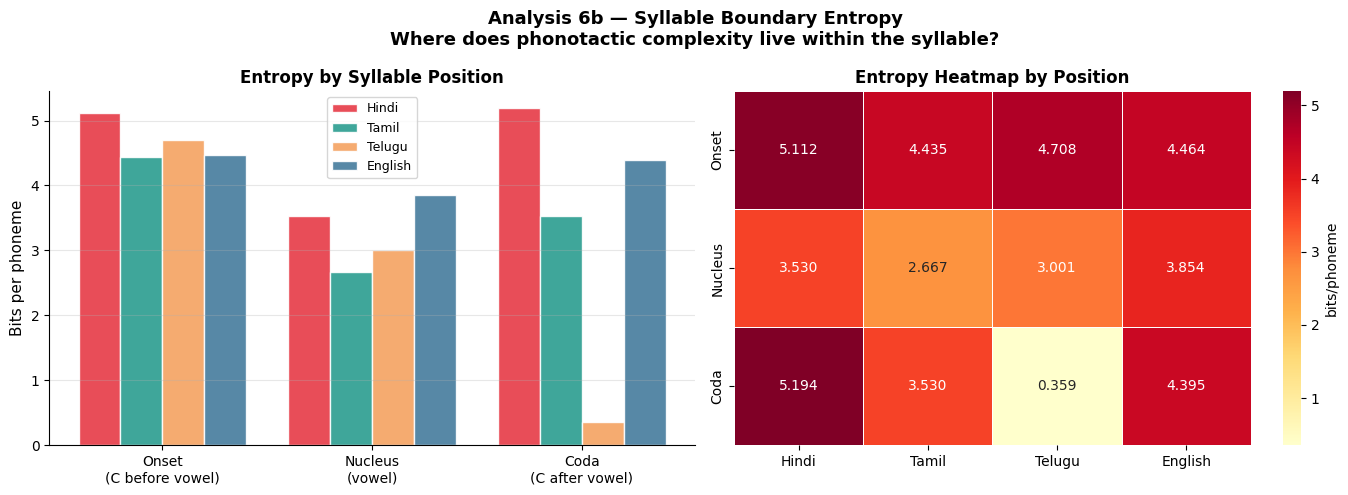

Saved: fig10_syllable_entropy.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Analysis 6b — Syllable Boundary Entropy\n"
             "Where does phonotactic complexity live within the syllable?",
             fontsize=13, fontweight="bold")

positions = ["onset", "nucleus", "coda"]

# Left: grouped bar chart
ax = axes[0]
x     = np.arange(len(positions))
width = 0.2

for i, lid in enumerate(LANGUAGES):
    vals   = [positional_results[lid][p] for p in positions]
    offset = (i - 1.5) * width
    ax.bar(x + offset, vals, width,
           label=LANG_NAMES[lid],
           color=LANG_COLORS[lid],
           edgecolor="white", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(["Onset\n(C before vowel)",
                    "Nucleus\n(vowel)",
                    "Coda\n(C after vowel)"], fontsize=10)
ax.set_ylabel("Bits per phoneme", fontsize=11)
ax.set_title("Entropy by Syllable Position", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

# Right: heatmap
ax2 = axes[1]
heatmap_data = pd.DataFrame(
    {LANG_NAMES[lid]: [positional_results[lid][p] for p in positions]
     for lid in LANGUAGES},
    index=["Onset", "Nucleus", "Coda"]
)
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlOrRd",
            ax=ax2, linewidths=0.5, cbar_kws={"label": "bits/phoneme"})
ax2.set_title("Entropy Heatmap by Position", fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/fig10_syllable_entropy.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig10_syllable_entropy.png")

In [9]:
# ── Retroflex IPA symbols across our three Indic languages ────────────────
RETROFLEXES = {"ʈ", "ɖ", "ɳ", "ɽ", "ɭ", "ʂ", "ɖʰ", "ʈʰ", "ɽʰ",
               "ɖʰː", "ʈʰː", "ʈː", "ɖː"}

# ── Non-retroflex consonants (for comparison baseline) ────────────────────
IPA_CONSONANTS = {
    "p","pʰ","b","bʰ","t","tʰ","d","dʰ","k","kʰ","g","gʰ",
    "m","n","ŋ","ɲ","l","r","s","z","ʃ","ʒ","h","v","w","j",
    "f","x","tʃ","dʒ","tʃʰ","dʒʰ","tɕ","dʑ","t̪","d̪","n̪",
    "ʋ","ɾ","ɻ","β","ð","θ","ɬ","ɹ",
}

print("Running retroflex positional entropy analysis...")
print(f"Retroflex symbols tracked: {sorted(RETROFLEXES)}")
print()

retroflex_results = {}

for lid in ["hin", "tam", "tel"]:  # English has no retroflexes
    retro_bits     = []
    non_retro_bits = []
    total_bits_all = []
    retro_count    = 0
    total_count    = 0

    for fold_data in splits[lid]:
        lm = InterpolatedNgramLM(n=3)
        lm.fit(fold_data["train"])

        for phonemes in fold_data["test"]:
            seq = lm._make_sequence(phonemes)
            for i in range(lm.n - 1, len(seq) - 1):
                context = tuple(seq[i - lm.n + 1 : i])
                sym     = seq[i]
                bits    = -math.log2(lm._interp_prob(context, sym))
                total_bits_all.append(bits)
                total_count += 1

                if sym in RETROFLEXES:
                    retro_bits.append(bits)
                    retro_count += 1
                elif sym in IPA_CONSONANTS:
                    non_retro_bits.append(bits)

    mean_retro     = np.mean(retro_bits)     if retro_bits     else 0
    mean_non_retro = np.mean(non_retro_bits) if non_retro_bits else 0
    retro_pct      = 100 * retro_count / total_count
    total_mean     = np.mean(total_bits_all)

    # Retroflex contribution = bits at retroflex positions × their frequency
    retro_contribution = mean_retro * (retro_count / total_count)
    pct_of_complexity  = 100 * retro_contribution / total_mean

    retroflex_results[lid] = {
        "mean_retro_bits"    : mean_retro,
        "mean_non_retro_bits": mean_non_retro,
        "retro_frequency"    : retro_pct,
        "pct_of_complexity"  : pct_of_complexity,
        "retro_count"        : retro_count,
        "total_count"        : total_count,
    }

    print(f"── {LANG_NAMES[lid]} ───────────────────────────────────────")
    print(f"  Retroflex positions: {retro_count} / {total_count} "
          f"({retro_pct:.1f}% of all phoneme positions)")
    print(f"  Avg bits at retroflex positions:     {mean_retro:.3f}")
    print(f"  Avg bits at non-retroflex consonants:{mean_non_retro:.3f}")
    print(f"  Retroflex surprise premium:          "
          f"{mean_retro - mean_non_retro:+.3f} bits")
    print(f"  Retroflex contribution to total:     "
          f"{pct_of_complexity:.1f}% of total complexity")
    print()

Running retroflex positional entropy analysis...
Retroflex symbols tracked: ['ɖ', 'ɖʰ', 'ɖʰː', 'ɖː', 'ɭ', 'ɳ', 'ɽ', 'ɽʰ', 'ʂ', 'ʈ', 'ʈʰ', 'ʈʰː', 'ʈː']

── Hindi ───────────────────────────────────────
  Retroflex positions: 218 / 5185 (4.2% of all phoneme positions)
  Avg bits at retroflex positions:     6.812
  Avg bits at non-retroflex consonants:4.864
  Retroflex surprise premium:          +1.948 bits
  Retroflex contribution to total:     6.4% of total complexity

── Tamil ───────────────────────────────────────
  Retroflex positions: 295 / 4482 (6.6% of all phoneme positions)
  Avg bits at retroflex positions:     4.579
  Avg bits at non-retroflex consonants:4.024
  Retroflex surprise premium:          +0.555 bits
  Retroflex contribution to total:     8.6% of total complexity

── Telugu ───────────────────────────────────────
  Retroflex positions: 295 / 4709 (6.3% of all phoneme positions)
  Avg bits at retroflex positions:     5.293
  Avg bits at non-retroflex consonants:4.332


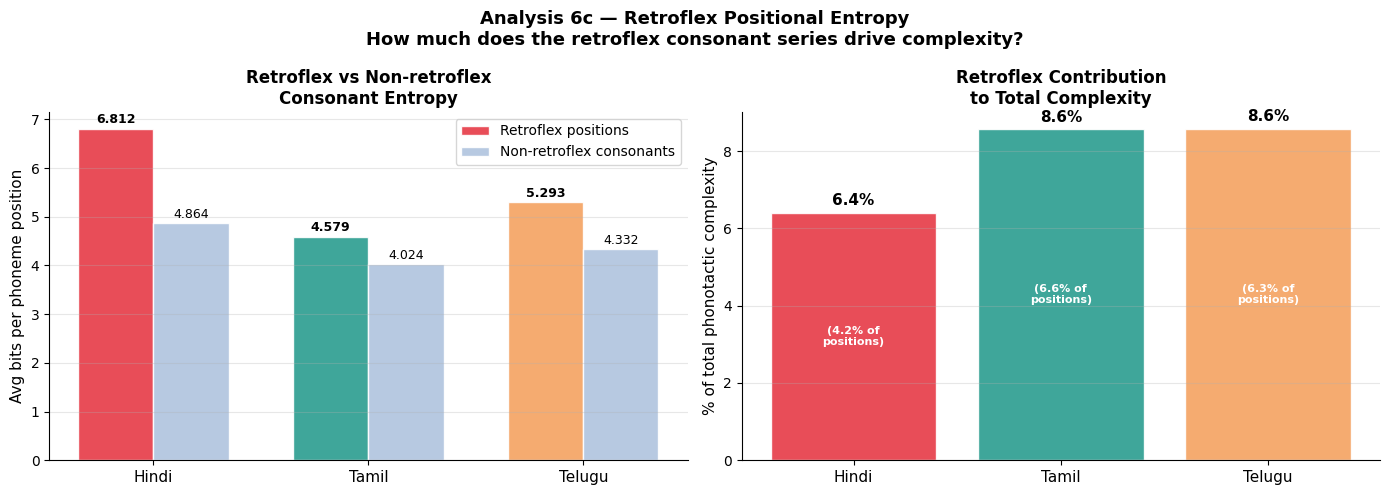

Saved: fig11_retroflex_entropy.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Analysis 6c — Retroflex Positional Entropy\n"
             "How much does the retroflex consonant series drive complexity?",
             fontsize=13, fontweight="bold")

indic_langs = ["hin", "tam", "tel"]

# Left: retroflex vs non-retroflex bits per language
ax = axes[0]
x     = np.arange(len(indic_langs))
width = 0.35

retro_means     = [retroflex_results[l]["mean_retro_bits"]     for l in indic_langs]
non_retro_means = [retroflex_results[l]["mean_non_retro_bits"] for l in indic_langs]

b1 = ax.bar(x - width/2, retro_means, width,
            label="Retroflex positions",
            color=[LANG_COLORS[l] for l in indic_langs],
            edgecolor="white", alpha=0.9)
b2 = ax.bar(x + width/2, non_retro_means, width,
            label="Non-retroflex consonants",
            color="lightsteelblue",
            edgecolor="white", alpha=0.9)

ax.bar_label(b1, fmt="{:.3f}", padding=2, fontsize=9, fontweight="bold")
ax.bar_label(b2, fmt="{:.3f}", padding=2, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([LANG_NAMES[l] for l in indic_langs], fontsize=11)
ax.set_ylabel("Avg bits per phoneme position", fontsize=11)
ax.set_title("Retroflex vs Non-retroflex\nConsonant Entropy",
             fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

# Right: % of total complexity from retroflexes
ax2 = axes[1]
pct_values = [retroflex_results[l]["pct_of_complexity"] for l in indic_langs]
freq_values = [retroflex_results[l]["retro_frequency"]   for l in indic_langs]

bars = ax2.bar(x, pct_values,
               color=[LANG_COLORS[l] for l in indic_langs],
               edgecolor="white", alpha=0.9)
ax2.bar_label(bars, fmt="{:.1f}%", padding=3,
              fontweight="bold", fontsize=11)

# Add frequency annotation
for i, (bar, freq) in enumerate(zip(bars, freq_values)):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() / 2,
             f"({freq:.1f}% of\npositions)",
             ha="center", va="center",
             fontsize=8, color="white", fontweight="bold")

ax2.set_xticks(x)
ax2.set_xticklabels([LANG_NAMES[l] for l in indic_langs], fontsize=11)
ax2.set_ylabel("% of total phonotactic complexity", fontsize=11)
ax2.set_title("Retroflex Contribution\nto Total Complexity",
              fontweight="bold")
ax2.spines[["top","right"]].set_visible(False)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/fig11_retroflex_entropy.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig11_retroflex_entropy.png")

In [11]:
print("━"*75)
print("COMPLETE PROJECT RESULTS SUMMARY")
print("Phonotactic Complexity of Indic Languages")
print("━"*75)

summary = []
for lid in LANGUAGES:
    r = {
        "Language"         : LANG_NAMES[lid],
        "Family"           : "Indo-Aryan" if lid=="hin" else
                             "Dravidian"  if lid in ("tam","tel") else
                             "Germanic",
        "Phoneme inv."     : len(set(p for e in forms[lid]
                                     for p in e["phonemes"])),
        "Avg word len"     : round(np.mean([len(e["phonemes"])
                                   for e in forms[lid]]), 2),
        "Trigram bpp"      : round(np.mean(ngram_results[lid]), 3),
        "LSTM bpp"         : round(np.mean(lstm_results[lid]), 3),
        "LSTM gain"        : round(np.mean(ngram_results[lid]) -
                                   np.mean(lstm_results[lid]), 3),
        "mBERT fertility"  : None,   # fill below
        "XLM-R fertility"  : None,
    }
    summary.append(r)

summary_df = pd.DataFrame(summary).set_index("Language")
print(summary_df.to_string())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
COMPLETE PROJECT RESULTS SUMMARY
Phonotactic Complexity of Indic Languages
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              Family  Phoneme inv.  Avg word len  Trigram bpp  LSTM bpp  LSTM gain mBERT fertility XLM-R fertility
Language                                                                                                          
Hindi     Indo-Aryan            82          4.79        4.008     3.722      0.285            None            None
Tamil      Dravidian            48          6.06        3.226     3.119      0.107            None            None
Telugu     Dravidian            66          6.50        3.511     3.283      0.228            None            None
English     Germanic            40          4.15        3.690     3.486      0.204            None            None


In [17]:
# Save all Notebook 6 results
nb6_results = {
    "vowel_harmony_ablation": {
        lid: {
            "normal_mean"   : float(np.mean(ablation_results[lid]["normal"])),
            "scrambled_mean": float(np.mean(ablation_results[lid]["scrambled"])),
            "contribution"  : float(harmony_contributions[lid]),
        }
        for lid in ["tel", "hin", "eng"]
    },
    "syllable_positional_entropy": {
        lid: positional_results[lid]
        for lid in LANGUAGES
    },
    "retroflex_analysis": {
        lid: {k: float(v) for k, v in retroflex_results[lid].items()
              if isinstance(v, (int, float, np.floating))}
        for lid in ["hin", "tam", "tel"]
    },
}

with open("/kaggle/working/nb6_mechanistic_results.json", "w") as f:
    json.dump(nb6_results, f, indent=2)

summary_df.to_csv("/kaggle/working/table6_full_summary.csv")

print("Saved:")
print("  /kaggle/working/nb6_mechanistic_results.json")
print("  /kaggle/working/table6_full_summary.csv")
print("  /kaggle/working/fig9_vowel_harmony_ablation.png")
print("  /kaggle/working/fig10_syllable_entropy.png")
print("  /kaggle/working/fig11_retroflex_entropy.png")
print()

Saved:
  /kaggle/working/nb6_mechanistic_results.json
  /kaggle/working/table6_full_summary.csv
  /kaggle/working/fig9_vowel_harmony_ablation.png
  /kaggle/working/fig10_syllable_entropy.png
  /kaggle/working/fig11_retroflex_entropy.png

